In this notebook, we applied manual search to find an optimal parameters for Particle Filter.

The parameters to be tuned and their possible options are:
- Resampling algorithm: multinomial, redidual, stratified, and systematic resampling algorithm
- Number of samples: from 32 to 2048 samples.

Those parameters are chosen based on a balance between processing time and estimation error.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
sys.path.append('/app/src')
from data_loader import DataLoader
from configs import SetupEnum, ErrorEnum
from kalman_filters.particle_filter import ResamplingAlgorithms
from parameter_tuners.particle_filter_parameter_tuner import ParticleFilterParameterTuner


%matplotlib inline
np.random.seed(777)

In [2]:
algorithms = [ResamplingAlgorithms.MULTINOMIAL, 
              ResamplingAlgorithms.RESIDUAL, 
              ResamplingAlgorithms.STRATIFIED, 
              ResamplingAlgorithms.SYSTEMATIC]
n_samples = [int(n) for n in np.logspace(5, 11, base=2, num=7).tolist()]

params = {
    "n_samples": n_samples,
    "algorithms": algorithms,
}
n_samples

[32, 64, 128, 256, 512, 1024, 2048]

In [3]:
resampling_algorithm_str = {
    ResamplingAlgorithms.MULTINOMIAL: "MULTINOMIAL", 
    ResamplingAlgorithms.RESIDUAL: "RESIDUAL", 
    ResamplingAlgorithms.STRATIFIED: "STRATIFIED", 
    ResamplingAlgorithms.SYSTEMATIC: "SYSTEMATIC"
}

root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
file_export_path = os.path.join(root_path, "exports/particle_filter")

exporting_filename = os.path.join(file_export_path, "0033_best_params.json")

kitti_date = '2011_09_30'
kitti_drive = '0033'

run_filter = False
error_type = ErrorEnum.MAE

error_weight = 0.9

In [4]:
best_params = []
best_params_0 = []
best_params_10 = []
best_params_20 = []
best_params_30 = []
best_params_40 = []

------

# No dropout measurement data

In [5]:
vo_dropout_ratio = 0.
gps_dropout_ratio = 0.

## Setup1 (IMU, VO)

In [6]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.0
0.0


In [7]:
if run_filter:
    tuner_setup1.run()
else:
    tuner_setup1.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 818.06it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1579.229 m
Root Mean Squared Error: 1884.815 m
Maximum Error: 3668.97 m
--------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 560.82it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2824.441 m
Root Mean Squared Error: 3710.36 m
Maximum Error: 9409.055 m
--------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 97.9 m
Root Mean Squared Error: 253.331 m
Maximum Error: 1323.345 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:32<00:00, 49.59it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.911 m
Root Mean Squared Error: 5.5 m
Maximum Error: 16.173 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:03<00:00, 25.06it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.918 m
Root Mean Squared Error: 5.494 m
Maximum Error: 16.22 m
--------------------------------------------------

Experiment finished.


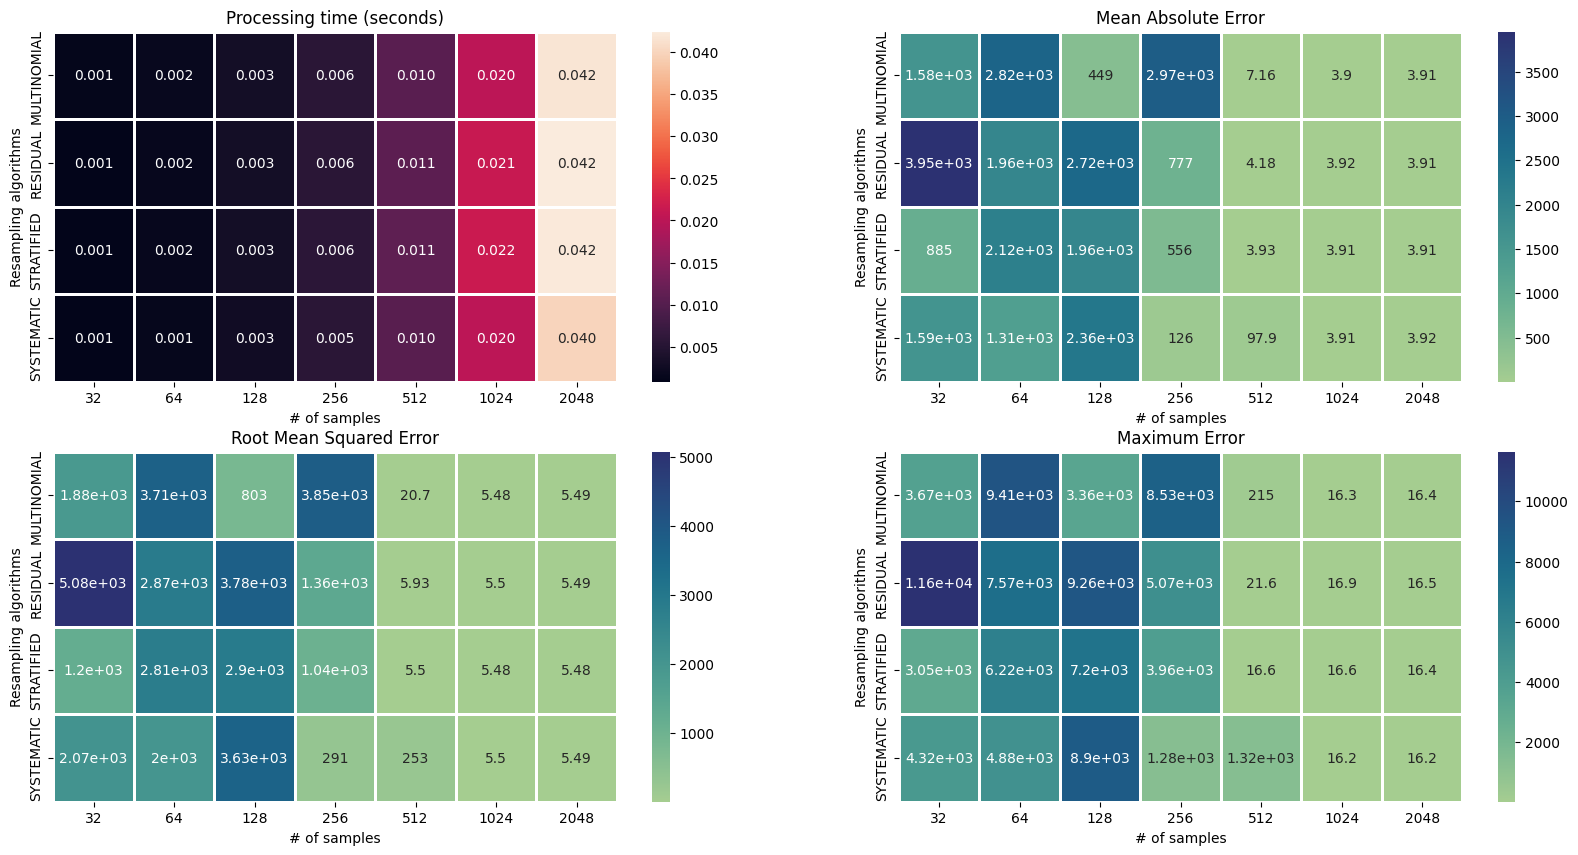

In [8]:
tuner_setup1.plot_results()

In [9]:
params_1_0, df_1_0 = tuner_setup1.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append(params_1_0)

In [10]:
df_1_0

,# of samples,resampling algorithm
MAE,512,STRATIFIED
RMSE,512,STRATIFIED
MAX,512,STRATIFIED


## Setup2 (IMU, VO+GPS)

In [11]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.0
0.0


In [12]:
if run_filter:
    tuner_setup2.run()
else:
    tuner_setup2.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 750.88it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2761.505 m
Root Mean Squared Error: 4170.964 m
Maximum Error: 10697.658 m
------------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 438.14it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2945.004 m
Root Mean Squared Error: 4016.745 m
Maximum Error: 8809.087 m
------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.564 m
Root Mean Squared Error: 0.708 m
Maximum Error: 2.664 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:51<00:00, 31.06it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.54 m
Root Mean Squared Error: 0.684 m
Maximum Error: 2.771 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:41<00:00, 15.70it/s]


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.539 m
Root Mean Squared Error: 0.681 m
Maximum Error: 2.541 m
------------------------------------------------------

Experiment finished.


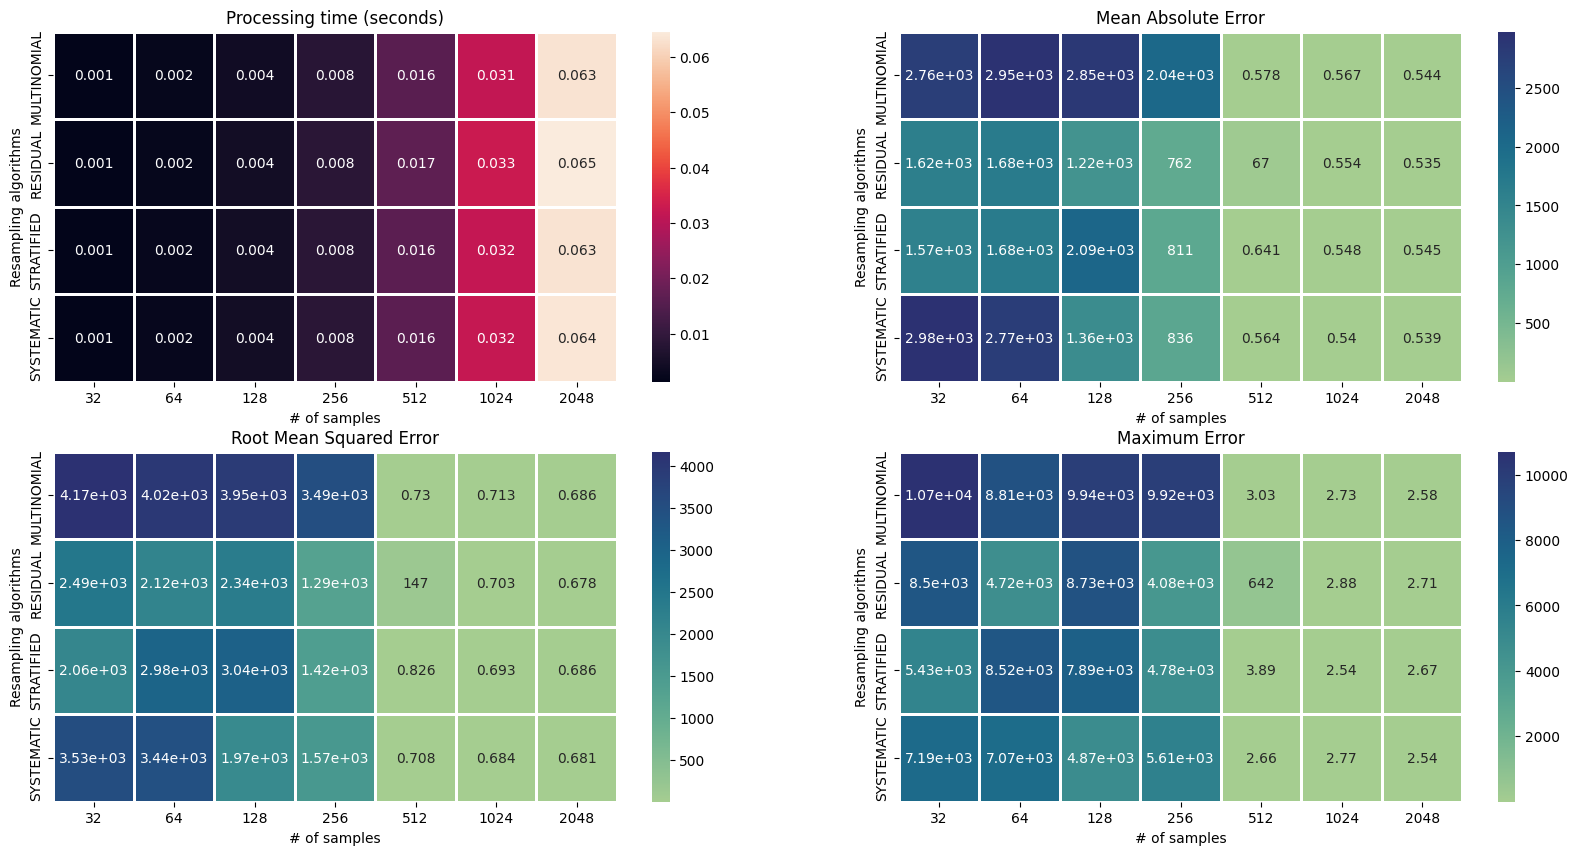

In [13]:
tuner_setup2.plot_results()

In [14]:
params_2_0, df_2_0 = tuner_setup2.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_0.append(params_2_0)

In [15]:
df_2_0

,# of samples,resampling algorithm
MAE,512,MULTINOMIAL
RMSE,512,MULTINOMIAL
MAX,512,MULTINOMIAL


## Setup3 (INS)

In [16]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.0
0.0


In [17]:
if run_filter:
    tuner_setup3.run()
else:
    tuner_setup3.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 962.24it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 84.85 m
Root Mean Squared Error: 131.881 m
Maximum Error: 347.888 m
----------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 560.26it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.484 m
Root Mean Squared Error: 0.621 m
Maximum Error: 2.6 m
----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.424 m
Root Mean Squared Error: 0.544 m
Maximum Error: 2.209 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:38<00:00, 41.27it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.415 m
Root Mean Squared Error: 0.535 m
Maximum Error: 2.089 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:16<00:00, 20.86it/s]


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.412 m
Root Mean Squared Error: 0.531 m
Maximum Error: 1.962 m
----------------------------------------------

Experiment finished.


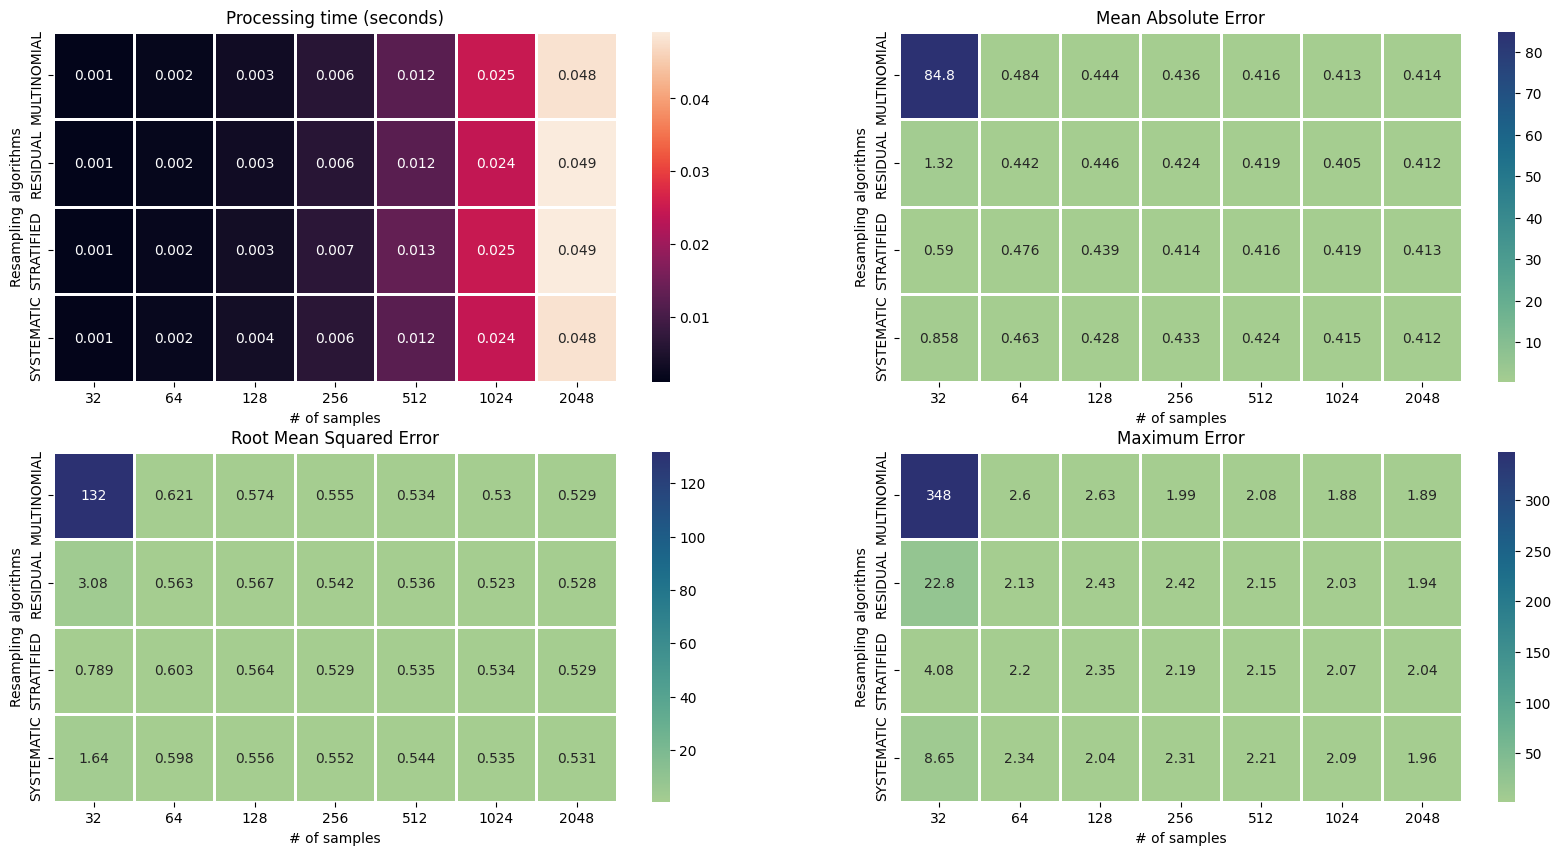

In [92]:
tuner_setup3.plot_results()

In [19]:
params_3_0, df_3_0 = tuner_setup3.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)
best_params_0.append(params_3_0)

In [20]:
df_3_0

,# of samples,resampling algorithm
MAE,64,RESIDUAL
RMSE,64,RESIDUAL
MAX,64,RESIDUAL


# 10% dropout measurement data

In [21]:
vo_dropout_ratio = 0.1
gps_dropout_ratio = 0.1

## Setup1 (IMU, VO)

In [22]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.1
0.1


In [23]:
if run_filter:
    tuner_setup1_10.run()
else:
    tuner_setup1_10.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1228.15it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2341.907 m
Root Mean Squared Error: 2906.998 m
Maximum Error: 4927.741 m
--------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 730.00it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1451.461 m
Root Mean Squared Error: 2213.971 m
Maximum Error: 5737.157 m
--------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.892 m
Root Mean Squared Error: 5.484 m
Maximum Error: 16.481 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:30<00:00, 51.72it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.896 m
Root Mean Squared Error: 5.492 m
Maximum Error: 16.92 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:59<00:00, 26.69it/s]


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.885 m
Root Mean Squared Error: 5.47 m
Maximum Error: 16.512 m
--------------------------------------------------

Experiment finished.


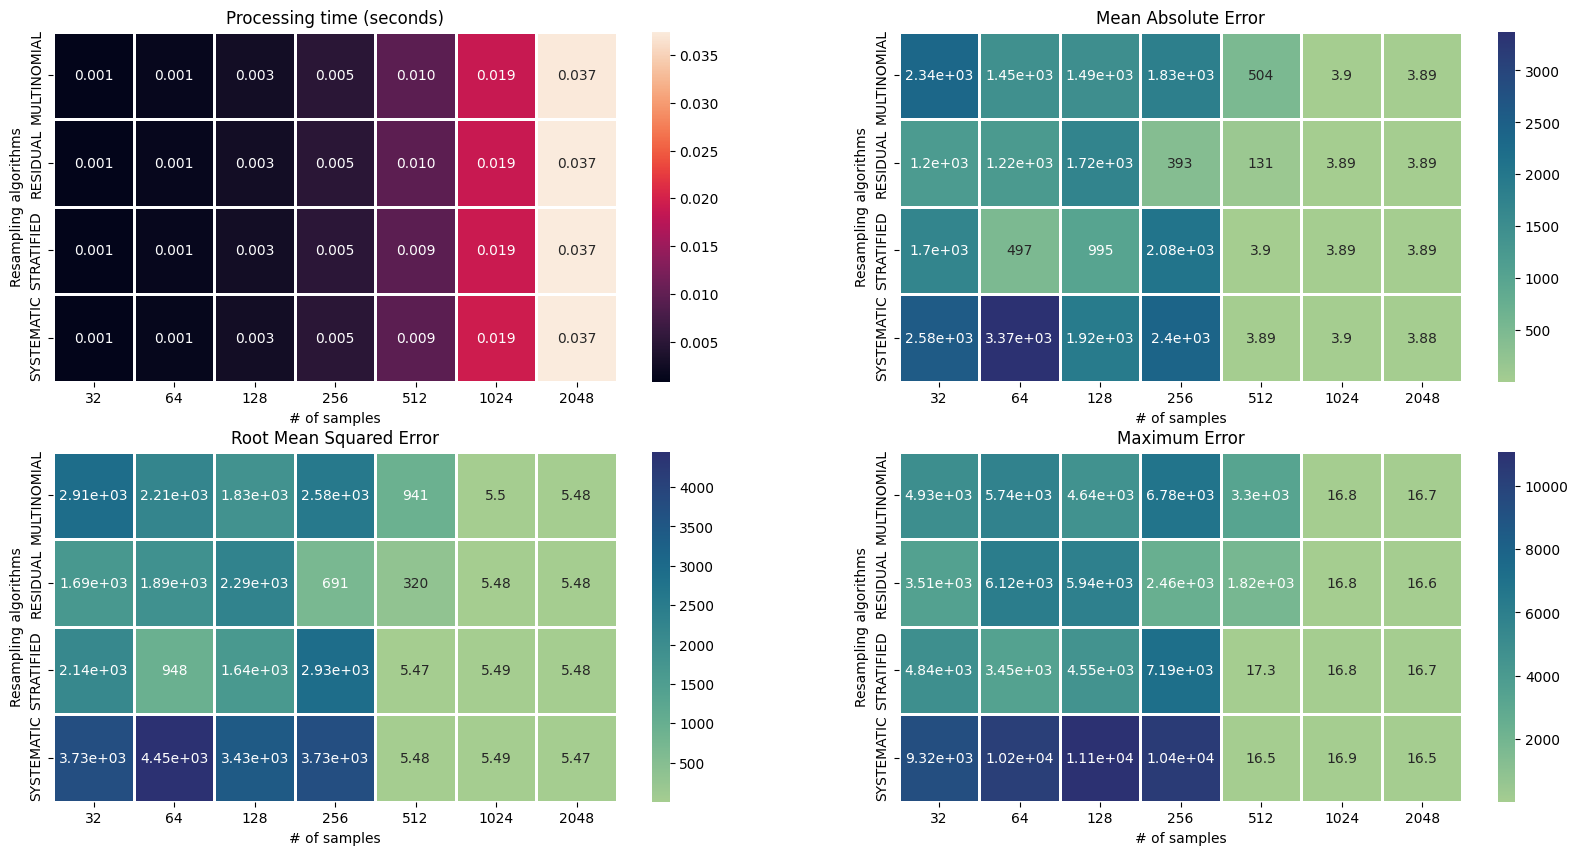

In [24]:
tuner_setup1_10.plot_results()

In [25]:
params_1_10, df_1_10 = tuner_setup1_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_1_10)

In [26]:
df_1_10

,# of samples,resampling algorithm
MAE,512,SYSTEMATIC
RMSE,512,STRATIFIED
MAX,512,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [27]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.1
0.1


In [28]:
if run_filter:
    tuner_setup2_10.run()
else:
    tuner_setup2_10.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 819.20it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1628.197 m
Root Mean Squared Error: 2007.041 m
Maximum Error: 4171.222 m
------------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 461.91it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2021.784 m
Root Mean Squared Error: 2589.78 m
Maximum Error: 6219.743 m
------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.713 m
Root Mean Squared Error: 0.993 m
Maximum Error: 7.429 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:47<00:00, 33.75it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.723 m
Root Mean Squared Error: 1.049 m
Maximum Error: 7.572 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:33<00:00, 16.99it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.705 m
Root Mean Squared Error: 1.041 m
Maximum Error: 7.742 m
------------------------------------------------------

Experiment finished.


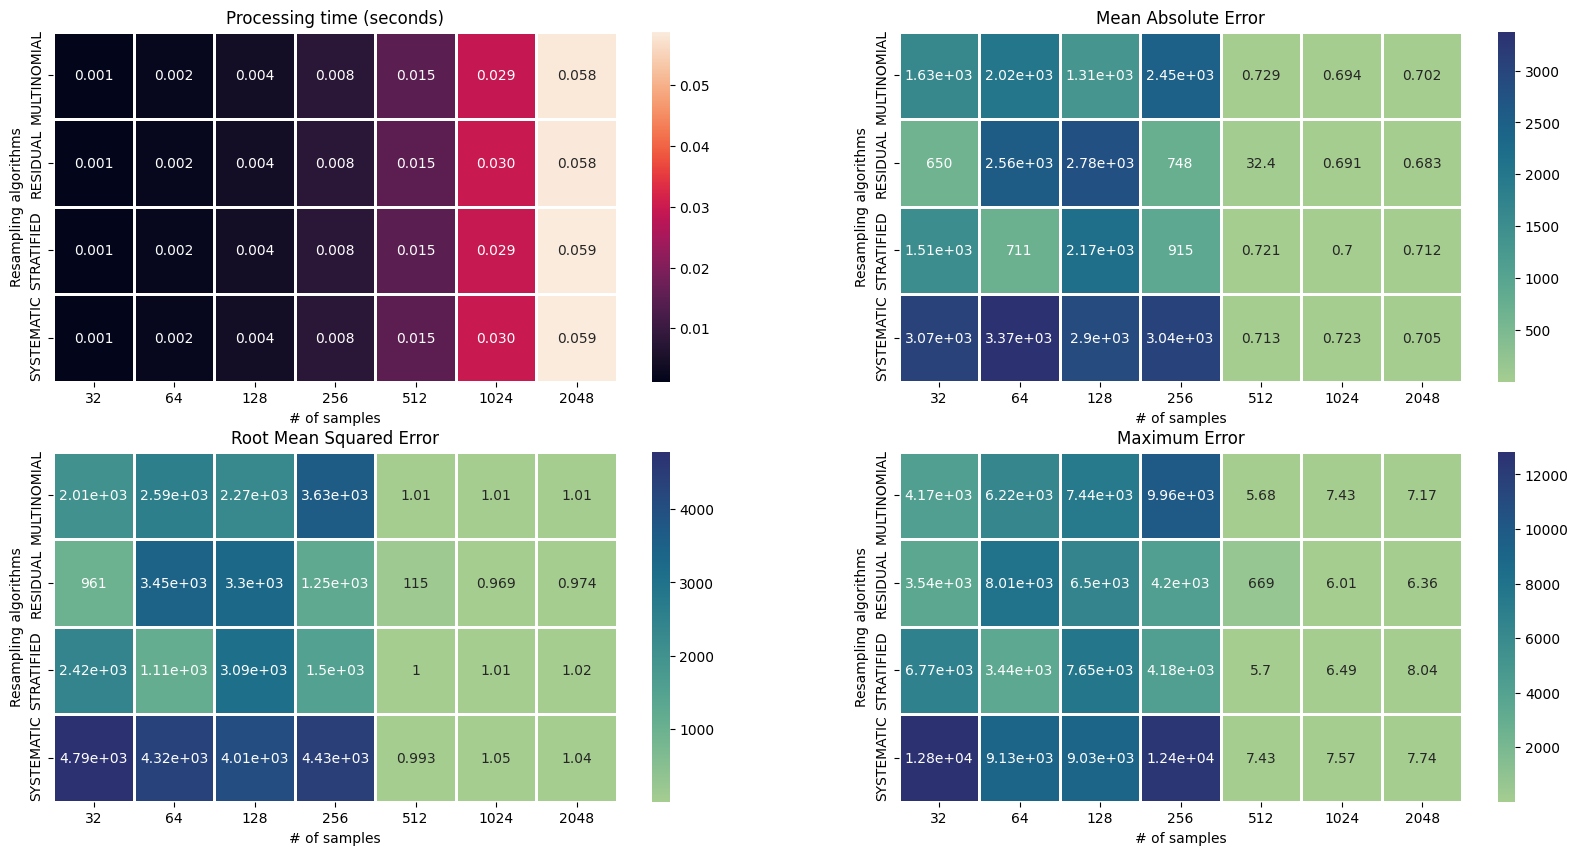

In [29]:
tuner_setup2_10.plot_results()

In [30]:
params_2_10, df_2_10 = tuner_setup2_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_2_10)

In [31]:
df_2_10

,# of samples,resampling algorithm
MAE,512,MULTINOMIAL
RMSE,512,MULTINOMIAL
MAX,512,MULTINOMIAL


## Setup3 (INS)

In [32]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_10 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.1
0.1


In [33]:
if run_filter:
    tuner_setup3_10.run()
else:
    tuner_setup3_10.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1071.32it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.592 m
Root Mean Squared Error: 0.802 m
Maximum Error: 6.095 m
----------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 627.27it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.568 m
Root Mean Squared Error: 0.788 m
Maximum Error: 5.2 m
----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.525 m
Root Mean Squared Error: 0.798 m
Maximum Error: 6.657 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:35<00:00, 45.12it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.528 m
Root Mean Squared Error: 0.832 m
Maximum Error: 7.491 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:09<00:00, 22.93it/s]


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.54 m
Root Mean Squared Error: 0.851 m
Maximum Error: 9.731 m
----------------------------------------------

Experiment finished.


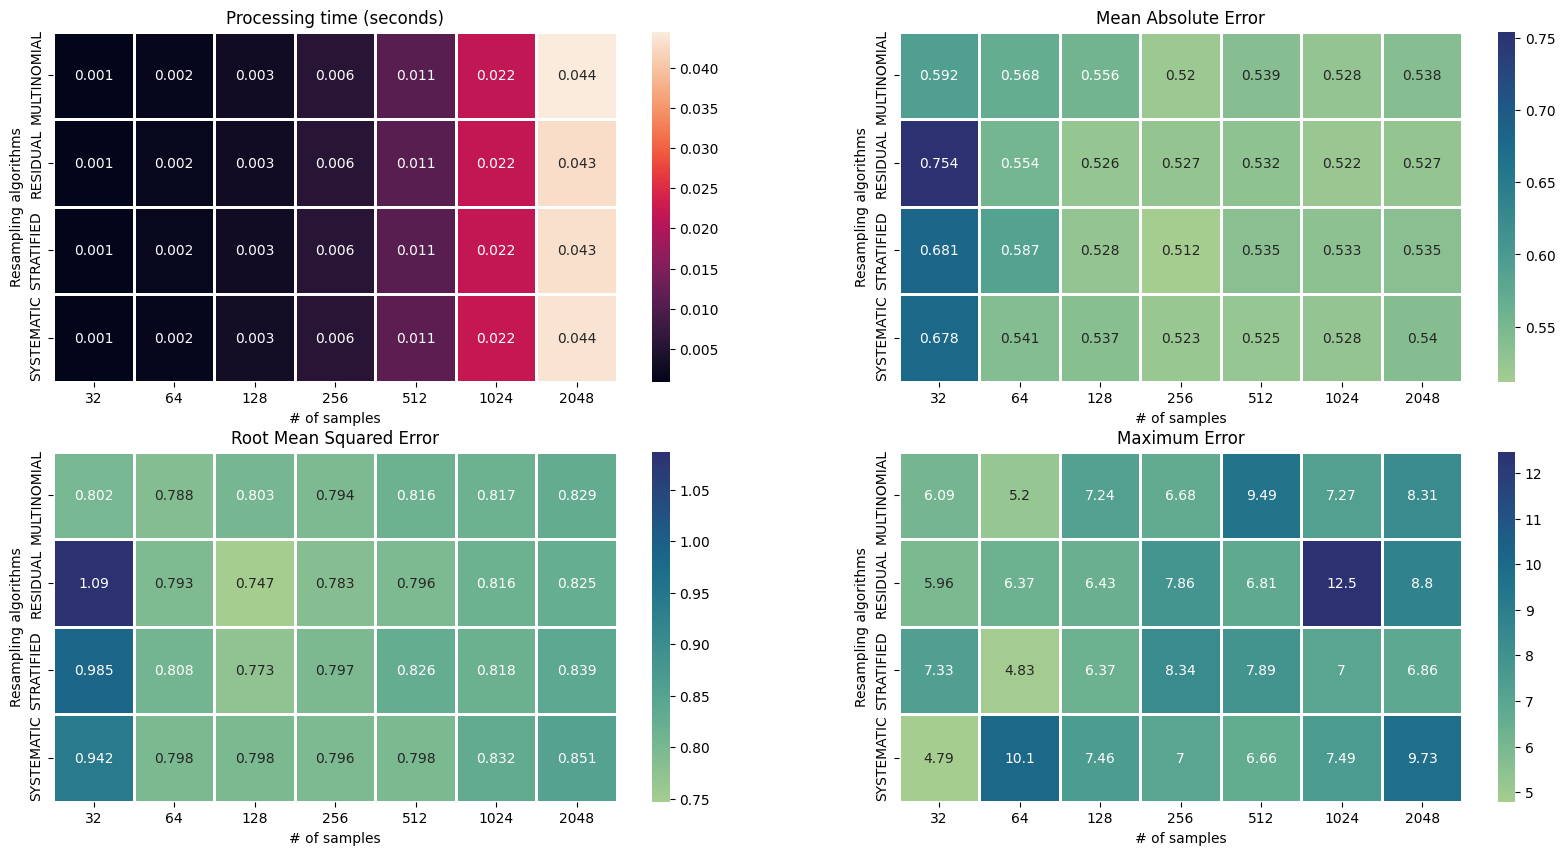

In [34]:
tuner_setup3_10.plot_results()

In [35]:
params_3_10, df_3_10 = tuner_setup3_10.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_10.append(params_3_10)

In [36]:
df_3_10

,# of samples,resampling algorithm
MAE,256,STRATIFIED
RMSE,128,RESIDUAL
MAX,32,SYSTEMATIC


# 20% dropout measurement data

In [37]:
vo_dropout_ratio = 0.2
gps_dropout_ratio = 0.2

## Setup1 (IMU, VO)

In [38]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.2
0.2


In [39]:
if run_filter:
    tuner_setup1_20.run()
else:
    tuner_setup1_20.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1338.67it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2157.208 m
Root Mean Squared Error: 2648.516 m
Maximum Error: 5334.869 m
--------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 770.46it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1840.047 m
Root Mean Squared Error: 2591.351 m
Maximum Error: 6812.883 m
--------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.905 m
Root Mean Squared Error: 5.504 m
Maximum Error: 17.329 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:27<00:00, 57.05it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.894 m
Root Mean Squared Error: 5.489 m
Maximum Error: 16.516 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:55<00:00, 28.43it/s]


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.885 m
Root Mean Squared Error: 5.473 m
Maximum Error: 16.398 m
--------------------------------------------------

Experiment finished.


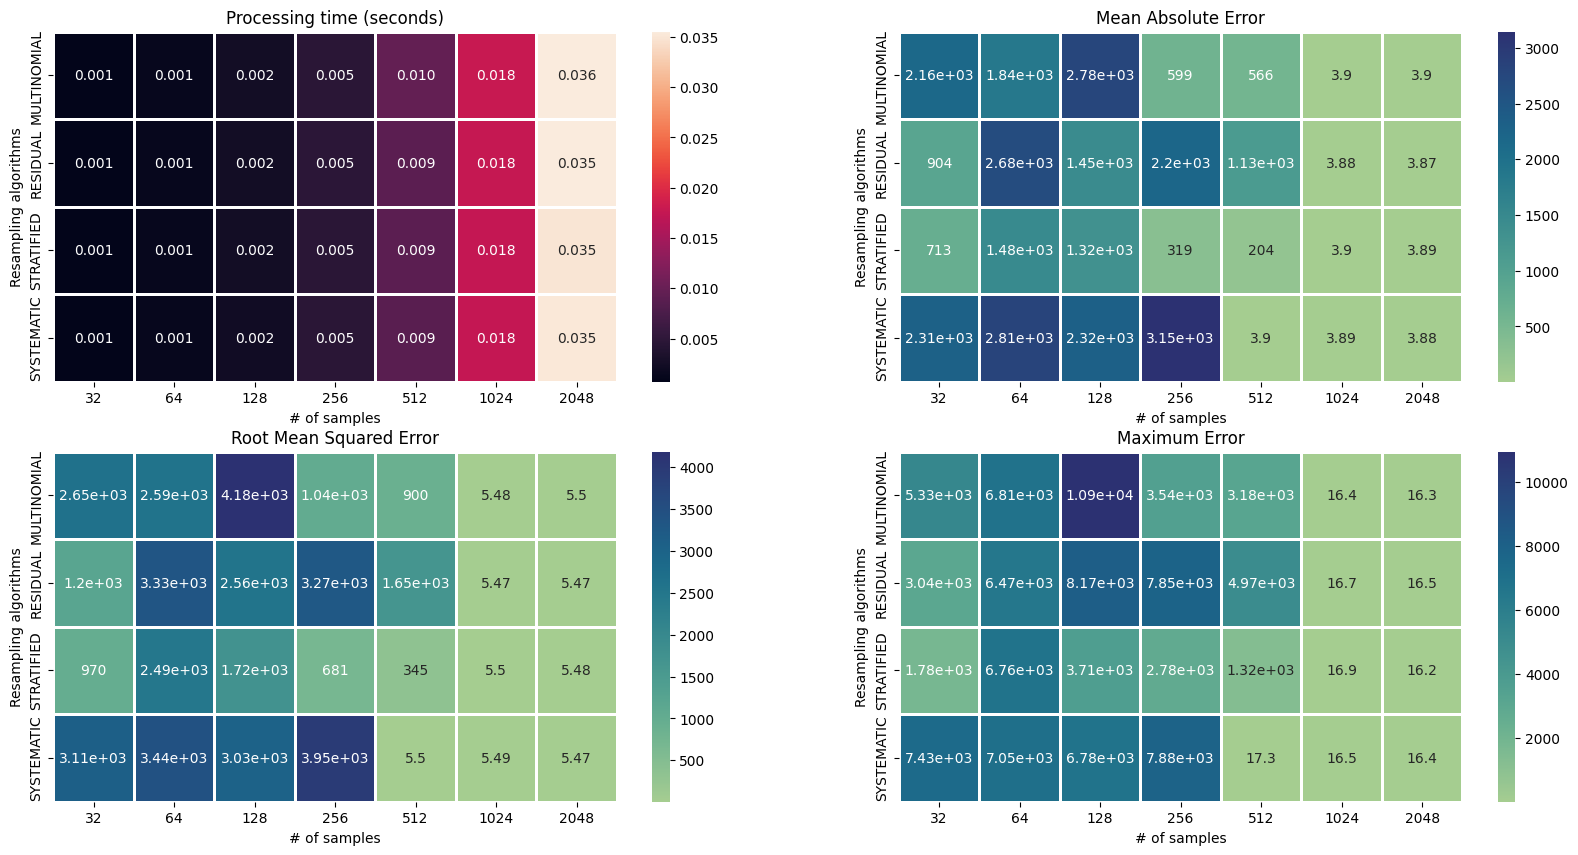

In [40]:
tuner_setup1_20.plot_results()

In [41]:
params_1_20, df_1_20 = tuner_setup1_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_1_20)

In [42]:
df_1_20

,# of samples,resampling algorithm
MAE,512,SYSTEMATIC
RMSE,512,SYSTEMATIC
MAX,512,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [43]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.2
0.2


In [44]:
if run_filter:
    tuner_setup2_20.run()
else:
    tuner_setup2_20.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 879.62it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 4142.51 m
Root Mean Squared Error: 5450.463 m
Maximum Error: 11412.577 m
------------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:03<00:00, 509.15it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 3030.568 m
Root Mean Squared Error: 3616.23 m
Maximum Error: 7520.323 m
------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2.097 m
Root Mean Squared Error: 9.06 m
Maximum Error: 125.913 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:43<00:00, 36.75it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.854 m
Root Mean Squared Error: 1.305 m
Maximum Error: 9.617 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:25<00:00, 18.51it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.844 m
Root Mean Squared Error: 1.297 m
Maximum Error: 8.053 m
------------------------------------------------------

Experiment finished.


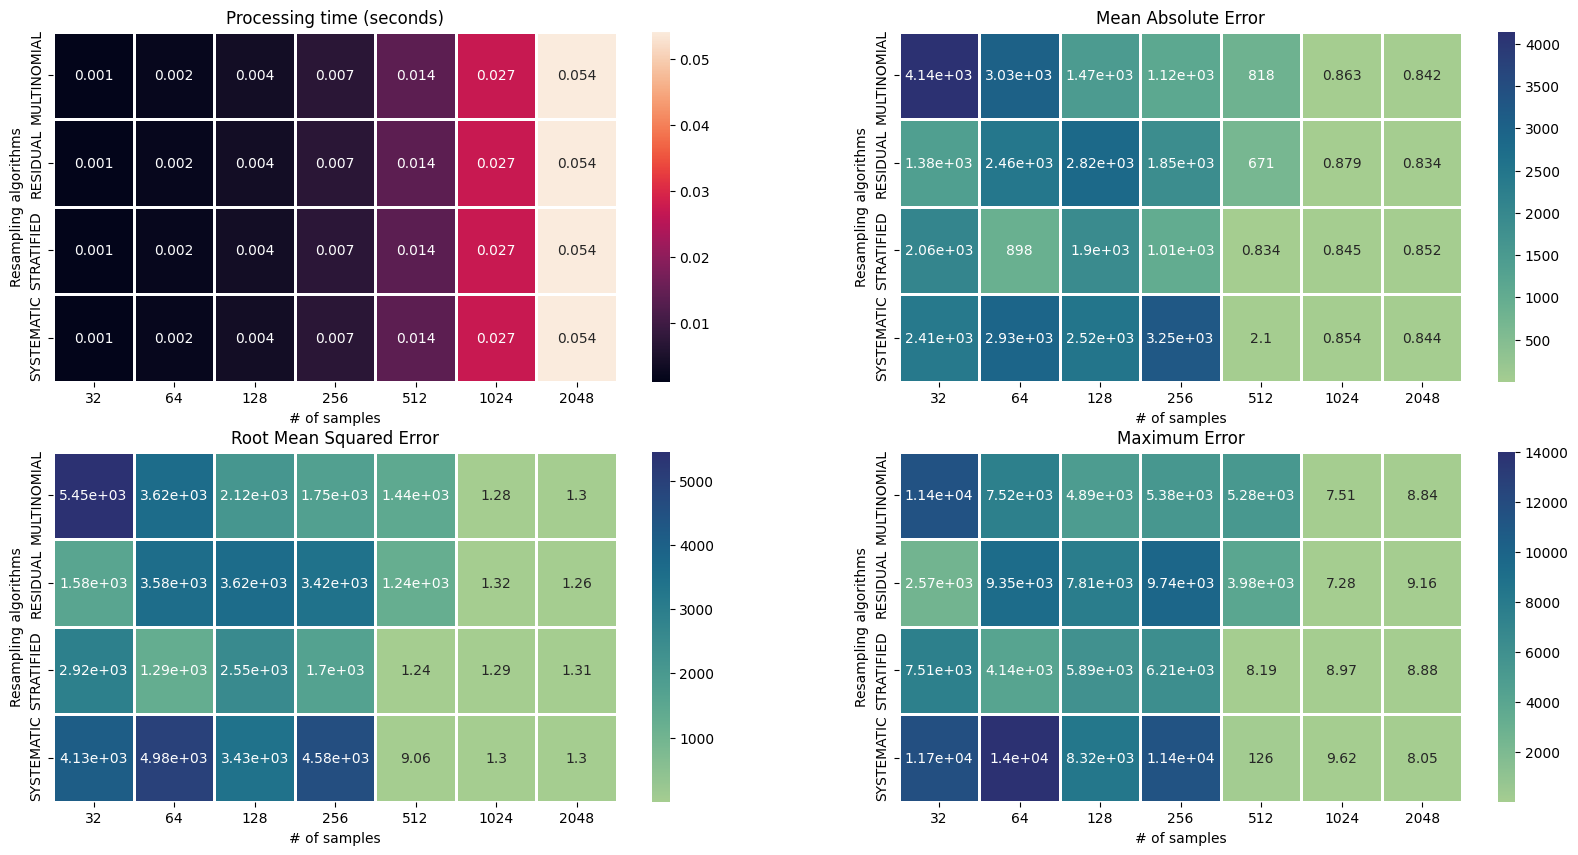

In [45]:
tuner_setup2_20.plot_results()

In [46]:
params_2_20, df_2_20 = tuner_setup2_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_2_20)

In [47]:
df_1_20

,# of samples,resampling algorithm
MAE,512,SYSTEMATIC
RMSE,512,SYSTEMATIC
MAX,512,SYSTEMATIC


## Setup3 (INS)

In [48]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_20 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.2
0.2


In [49]:
if run_filter:
    tuner_setup3_20.run()
else:
    tuner_setup3_20.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1179.94it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.739 m
Root Mean Squared Error: 1.053 m
Maximum Error: 5.689 m
----------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 696.01it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.618 m
Root Mean Squared Error: 0.899 m
Maximum Error: 6.553 m
----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.625 m
Root Mean Squared Error: 1.0 m
Maximum Error: 8.257 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:30<00:00, 51.63it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.618 m
Root Mean Squared Error: 1.012 m
Maximum Error: 7.991 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:01<00:00, 26.05it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.626 m
Root Mean Squared Error: 1.04 m
Maximum Error: 8.829 m
----------------------------------------------

Experiment finished.


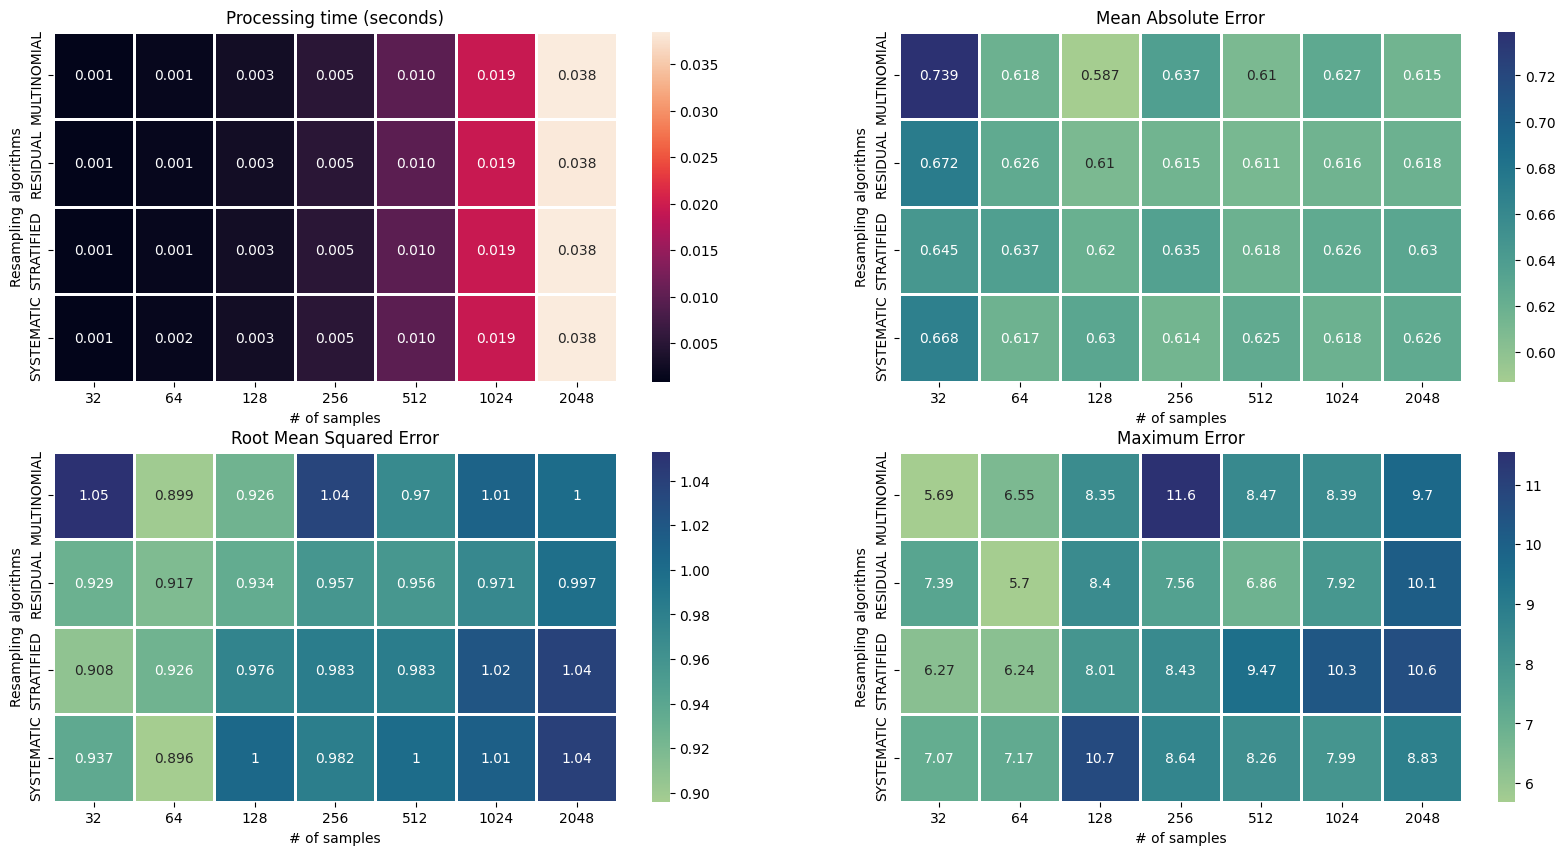

In [50]:
tuner_setup3_20.plot_results()

In [51]:
params_3_20, df_3_20 = tuner_setup3_20.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_20.append(params_3_20)

In [52]:
df_3_20

,# of samples,resampling algorithm
MAE,128,MULTINOMIAL
RMSE,64,SYSTEMATIC
MAX,32,MULTINOMIAL


# 30% dropout measurement data

In [53]:
vo_dropout_ratio = 0.3
gps_dropout_ratio = 0.3

## Setup1 (IMU, VO)

In [54]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.3
0.3


In [55]:
if run_filter:
    tuner_setup1_30.run()
else:
    tuner_setup1_30.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1465.48it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2301.377 m
Root Mean Squared Error: 3039.512 m
Maximum Error: 8036.568 m
--------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 848.40it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 2783.046 m
Root Mean Squared Error: 3782.718 m
Maximum Error: 8694.659 m
--------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 312.938 m
Root Mean Squared Error: 510.128 m
Maximum Error: 1778.361 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:26<00:00, 60.51it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.926 m
Root Mean Squared Error: 5.531 m
Maximum Error: 16.256 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:51<00:00, 30.63it/s]


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.921 m
Root Mean Squared Error: 5.526 m
Maximum Error: 16.458 m
--------------------------------------------------

Experiment finished.


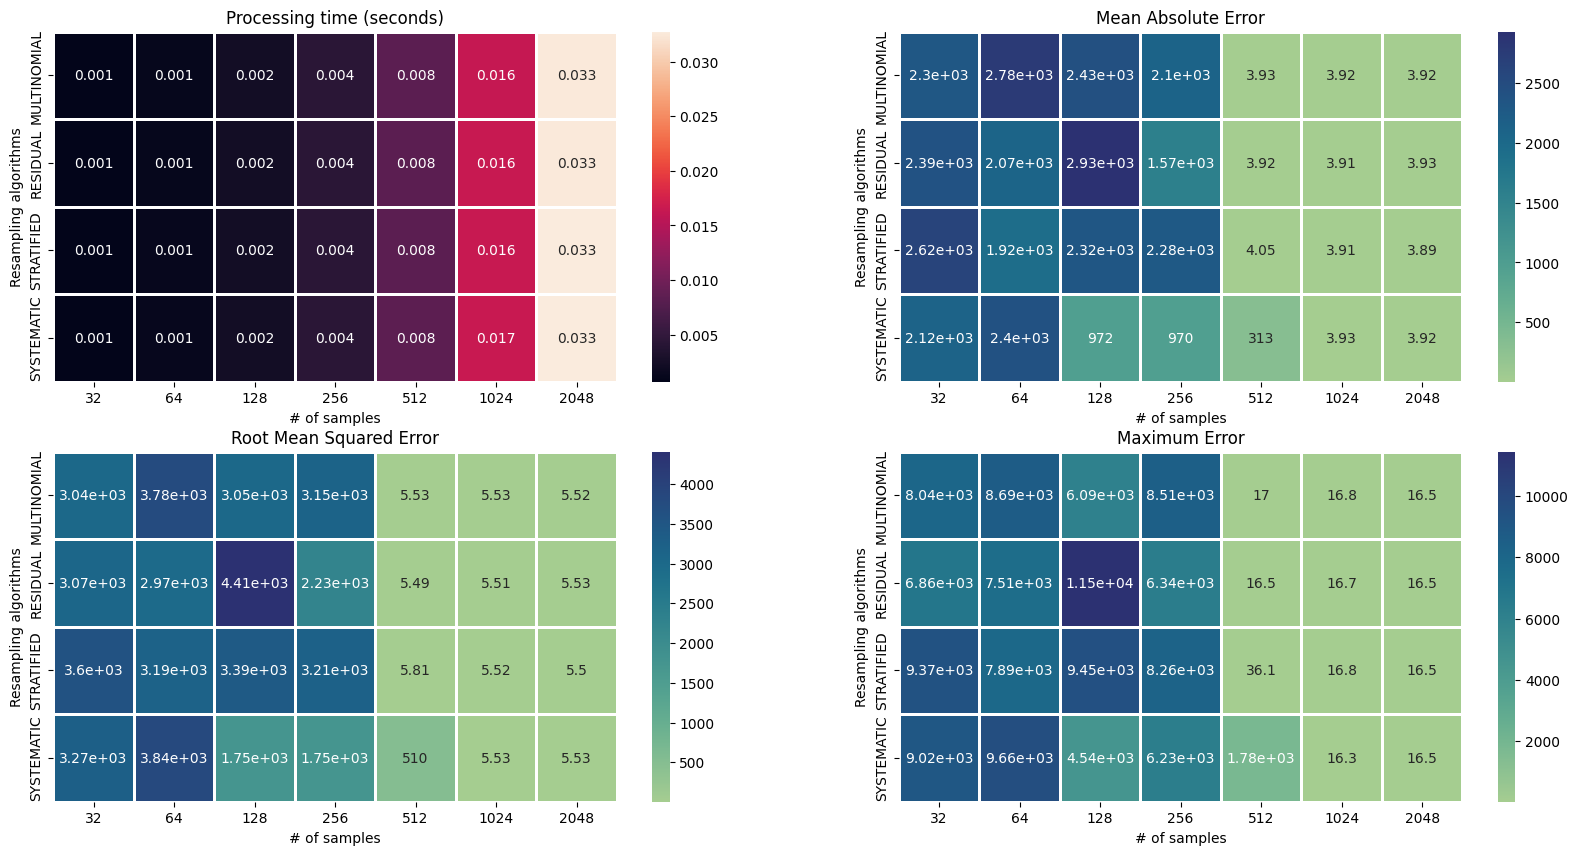

In [56]:
tuner_setup1_30.plot_results()

In [57]:
params_1_30, df_1_30 = tuner_setup1_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_1_30)

In [58]:
df_1_30

,# of samples,resampling algorithm
MAE,512,MULTINOMIAL
RMSE,512,MULTINOMIAL
MAX,512,RESIDUAL


## Setup2 (IMU, VO+GPS)

In [59]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.3
0.3


In [60]:
if run_filter:
    tuner_setup2_30.run()
else:
    tuner_setup2_30.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 971.04it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1151.941 m
Root Mean Squared Error: 1812.22 m
Maximum Error: 4725.167 m
------------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 561.64it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1521.184 m
Root Mean Squared Error: 2184.236 m
Maximum Error: 5754.004 m
------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 24.391 m
Root Mean Squared Error: 80.431 m
Maximum Error: 544.271 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:40<00:00, 39.08it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.978 m
Root Mean Squared Error: 1.493 m
Maximum Error: 10.324 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:22<00:00, 19.20it/s]


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.991 m
Root Mean Squared Error: 1.547 m
Maximum Error: 11.681 m
------------------------------------------------------

Experiment finished.


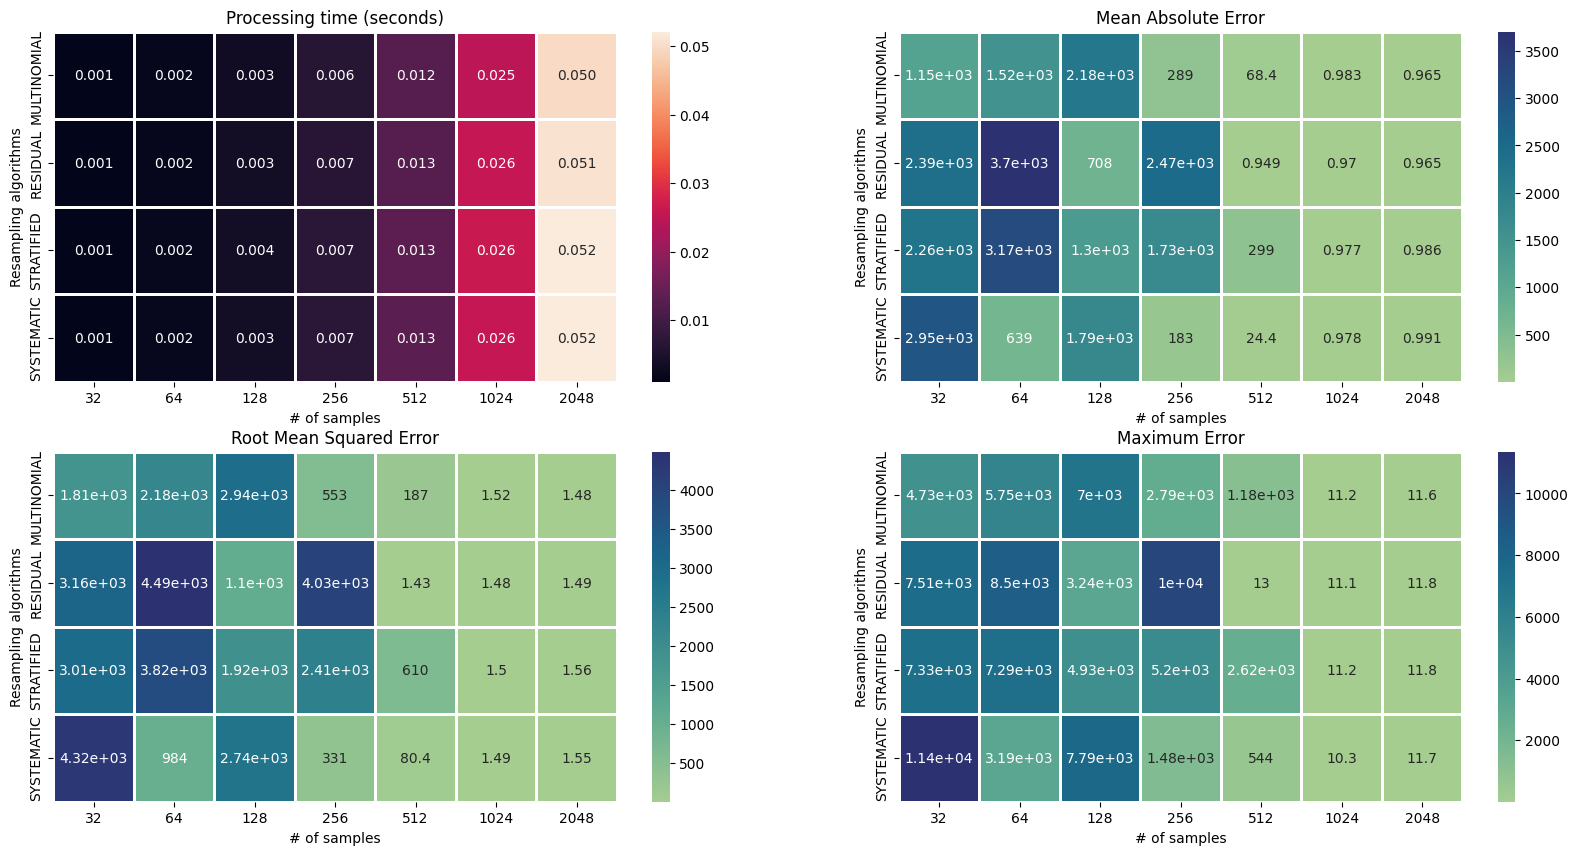

In [61]:
tuner_setup2_30.plot_results()

In [62]:
params_2_30, df_2_30 = tuner_setup2_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_2_30)

In [63]:
df_2_30

,# of samples,resampling algorithm
MAE,512,RESIDUAL
RMSE,512,RESIDUAL
MAX,512,RESIDUAL


## Setup3 (INS)

In [64]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_30 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.3
0.3


In [65]:
if run_filter:
    tuner_setup3_30.run()
else:
    tuner_setup3_30.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1136.61it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.761 m
Root Mean Squared Error: 1.051 m
Maximum Error: 6.669 m
----------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 651.75it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.726 m
Root Mean Squared Error: 1.098 m
Maximum Error: 9.273 m
----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.68 m
Root Mean Squared Error: 1.126 m
Maximum Error: 9.603 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:27<00:00, 58.72it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.699 m
Root Mean Squared Error: 1.209 m
Maximum Error: 11.042 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:57<00:00, 27.51it/s]


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.711 m
Root Mean Squared Error: 1.222 m
Maximum Error: 10.184 m
----------------------------------------------

Experiment finished.


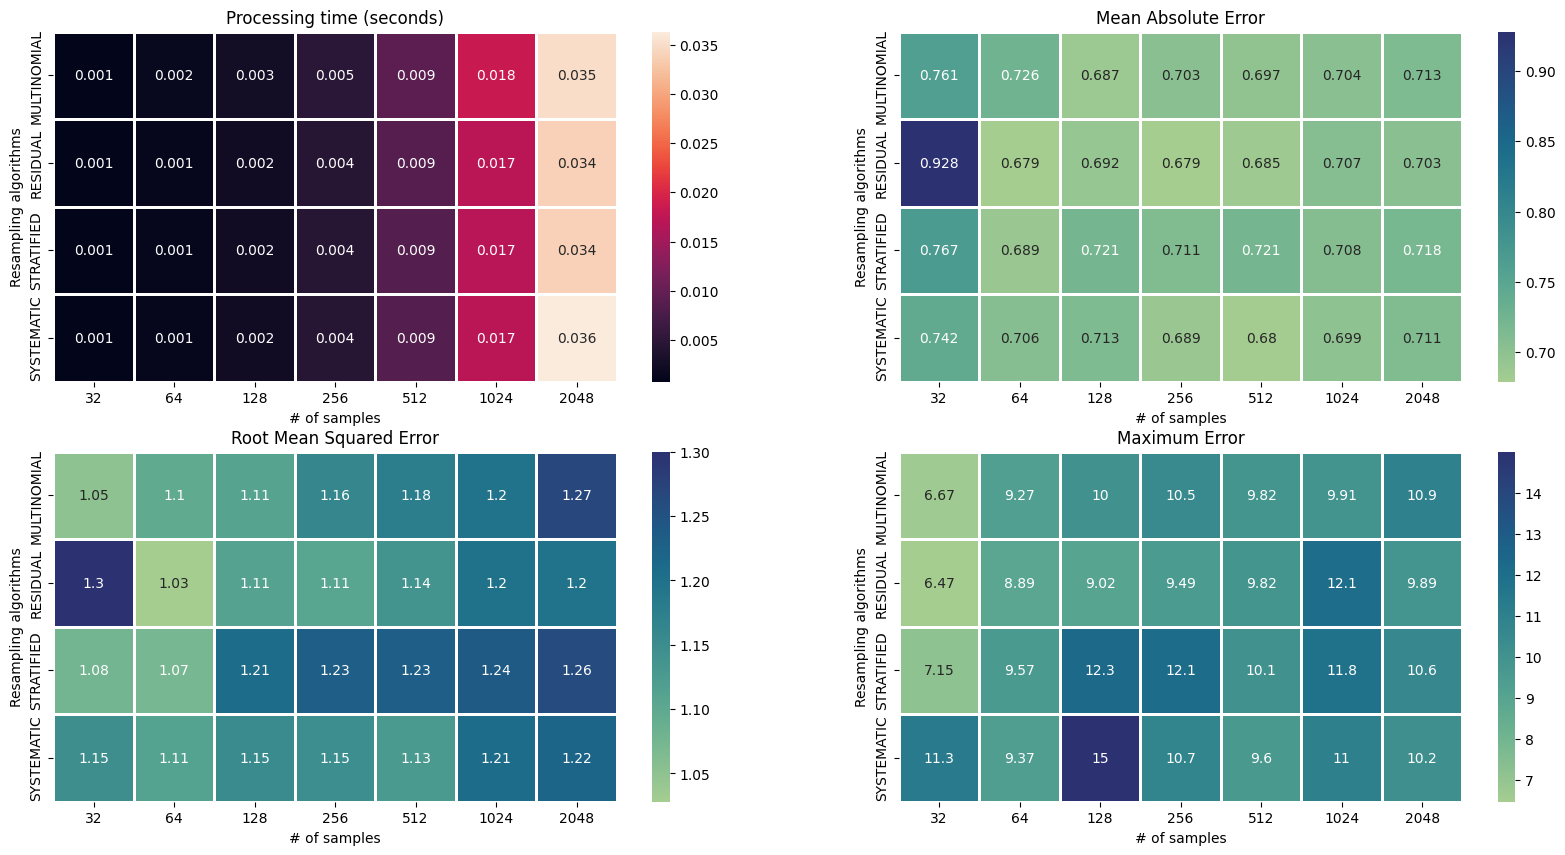

In [66]:
tuner_setup3_30.plot_results()

In [67]:
params_3_30, df_3_30 = tuner_setup3_30.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_30.append(params_3_30)

In [68]:
df_3_30

,# of samples,resampling algorithm
MAE,64,RESIDUAL
RMSE,64,RESIDUAL
MAX,32,RESIDUAL


# 40% dropout measurement data

In [69]:
vo_dropout_ratio = 0.4
gps_dropout_ratio = 0.4

## Setup1 (IMU, VO)

In [70]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup1_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_1,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.4
0.4


In [71]:
if run_filter:
    tuner_setup1_40.run()
else:
    tuner_setup1_40.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1513.79it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1710.824 m
Root Mean Squared Error: 2601.056 m
Maximum Error: 6882.133 m
--------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 879.50it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1400.127 m
Root Mean Squared Error: 2052.292 m
Maximum Error: 5452.346 m
--------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.939 m
Root Mean Squared Error: 5.522 m
Maximum Error: 17.993 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:24<00:00, 63.92it/s]



----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.908 m
Root Mean Squared Error: 5.486 m
Maximum Error: 16.882 m
--------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:49<00:00, 32.41it/s]


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 3.881 m
Root Mean Squared Error: 5.469 m
Maximum Error: 16.838 m
--------------------------------------------------

Experiment finished.


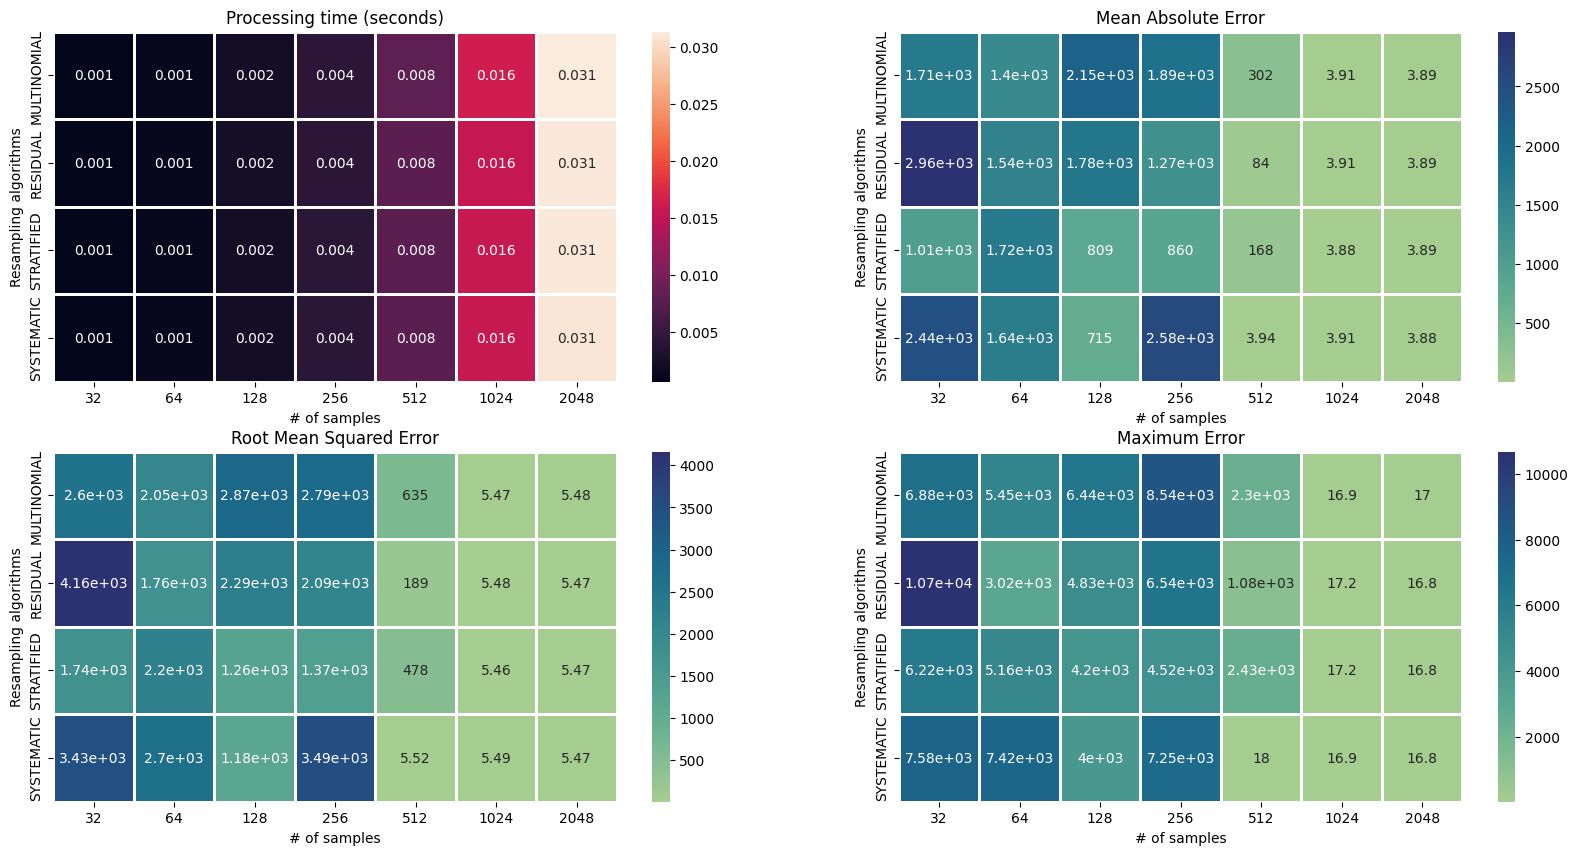

In [72]:
tuner_setup1_40.plot_results()

In [73]:
params_1_40, df_1_40 = tuner_setup1_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_1_40)

In [74]:
df_1_40

,# of samples,resampling algorithm
MAE,512,SYSTEMATIC
RMSE,512,SYSTEMATIC
MAX,512,SYSTEMATIC


## Setup2 (IMU, VO+GPS)

In [75]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup2_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_2,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.4
0.4


In [76]:
if run_filter:
    tuner_setup2_40.run()
else:
    tuner_setup2_40.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1068.79it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1952.313 m
Root Mean Squared Error: 2923.994 m
Maximum Error: 7533.016 m
------------------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:02<00:00, 603.14it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 2919.266 m
Root Mean Squared Error: 4010.629 m
Maximum Error: 9978.483 m
------------------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 662.867 m
Root Mean Squared Error: 1326.827 m
Maximum Error: 4554.381 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:36<00:00, 43.35it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.173 m
Root Mean Squared Error: 1.868 m
Maximum Error: 18.048 m
------------------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [01:11<00:00, 22.17it/s]



----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.149 m
Root Mean Squared Error: 1.844 m
Maximum Error: 18.72 m
------------------------------------------------------

Experiment finished.


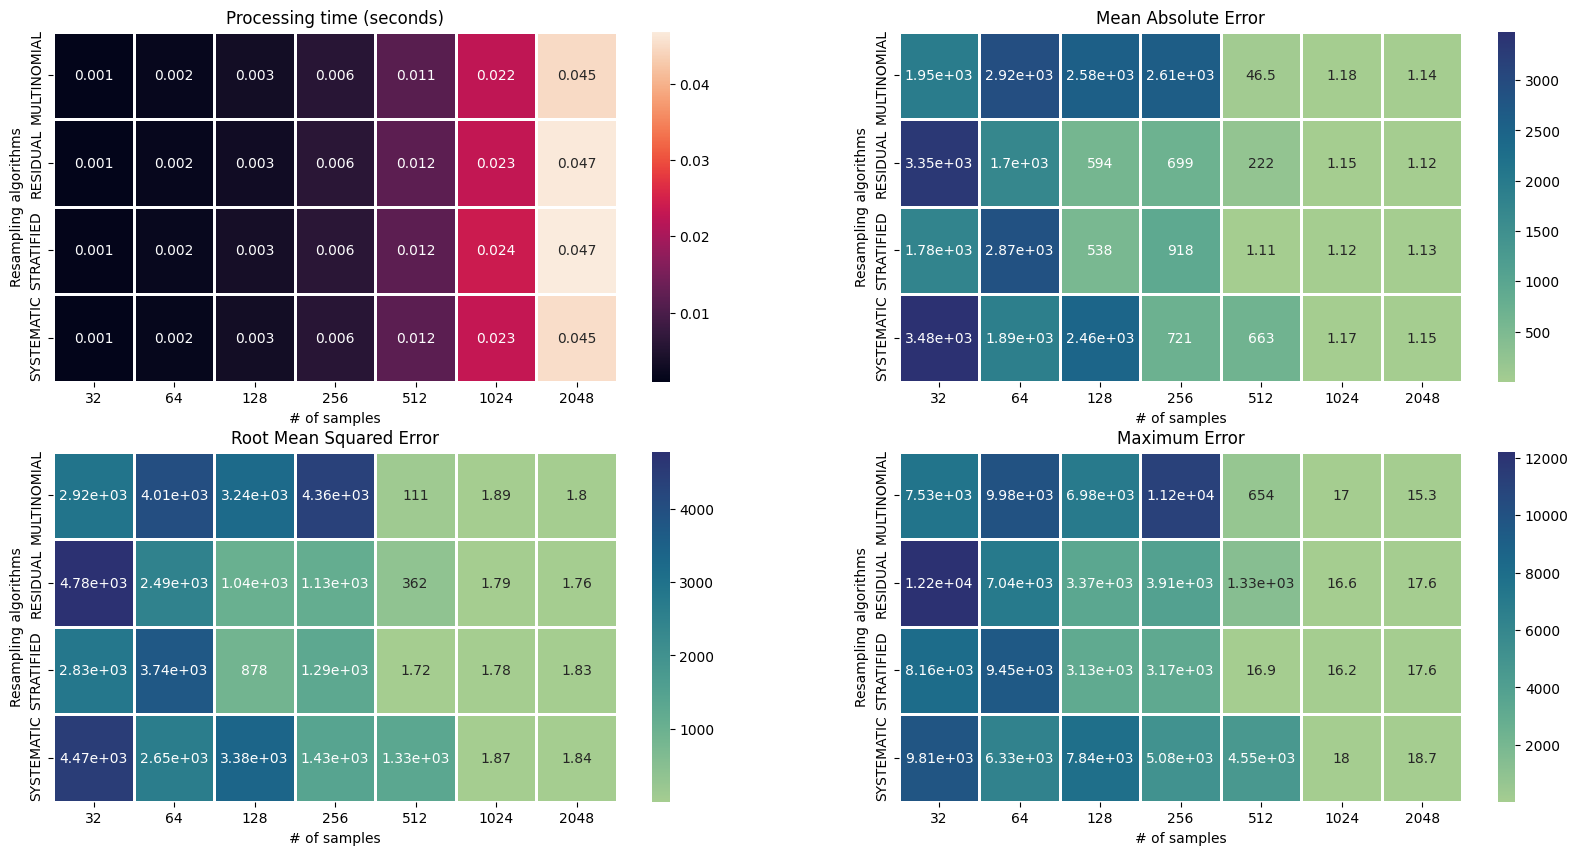

In [77]:
tuner_setup2_40.plot_results()

In [78]:
params_2_40, df_2_40 = tuner_setup2_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_2_40)

In [79]:
df_2_40

,# of samples,resampling algorithm
MAE,512,STRATIFIED
RMSE,512,STRATIFIED
MAX,512,STRATIFIED


## Setup3 (INS)

In [80]:
data = DataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    vo_root_dir=vo_root_dir,
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=vo_dropout_ratio, 
    gps_dropout_ratio=gps_dropout_ratio,
    visualize_data=False
)

tuner_setup3_40 = ParticleFilterParameterTuner(
    setup=SetupEnum.SETUP_3,
    params=params,
    data=data,
    kitti_drive=kitti_drive,
    file_export_path=file_export_path,
)

Data sampling is set to normal mode.
{'n_samples': [32, 64, 128, 256, 512, 1024, 2048], 'algorithms': [<ResamplingAlgorithms.MULTINOMIAL: 1>, <ResamplingAlgorithms.RESIDUAL: 2>, <ResamplingAlgorithms.STRATIFIED: 3>, <ResamplingAlgorithms.SYSTEMATIC: 4>]}
0.4
0.4


In [81]:
if run_filter:
    tuner_setup3_40.run()
else:
    tuner_setup3_40.load_df()

Resampled by: MULTINOMIAL
[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 1491.69it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.87 m
Root Mean Squared Error: 1.224 m
Maximum Error: 7.183 m
----------------------------------------------

[PF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:01<00:00, 876.47it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.858 m
Root Mean Squared Error: 1.257 m
Maximum Error: 8.407 m
----------------------------------------------

[PF] start.


...


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.823 m
Root Mean Squared Error: 1.319 m
Maximum Error: 9.29 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:23<00:00, 68.68it/s]



----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.855 m
Root Mean Squared Error: 1.435 m
Maximum Error: 11.706 m
----------------------------------------------

[PF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:46<00:00, 34.39it/s]


----- [PF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.878 m
Root Mean Squared Error: 1.51 m
Maximum Error: 11.983 m
----------------------------------------------

Experiment finished.


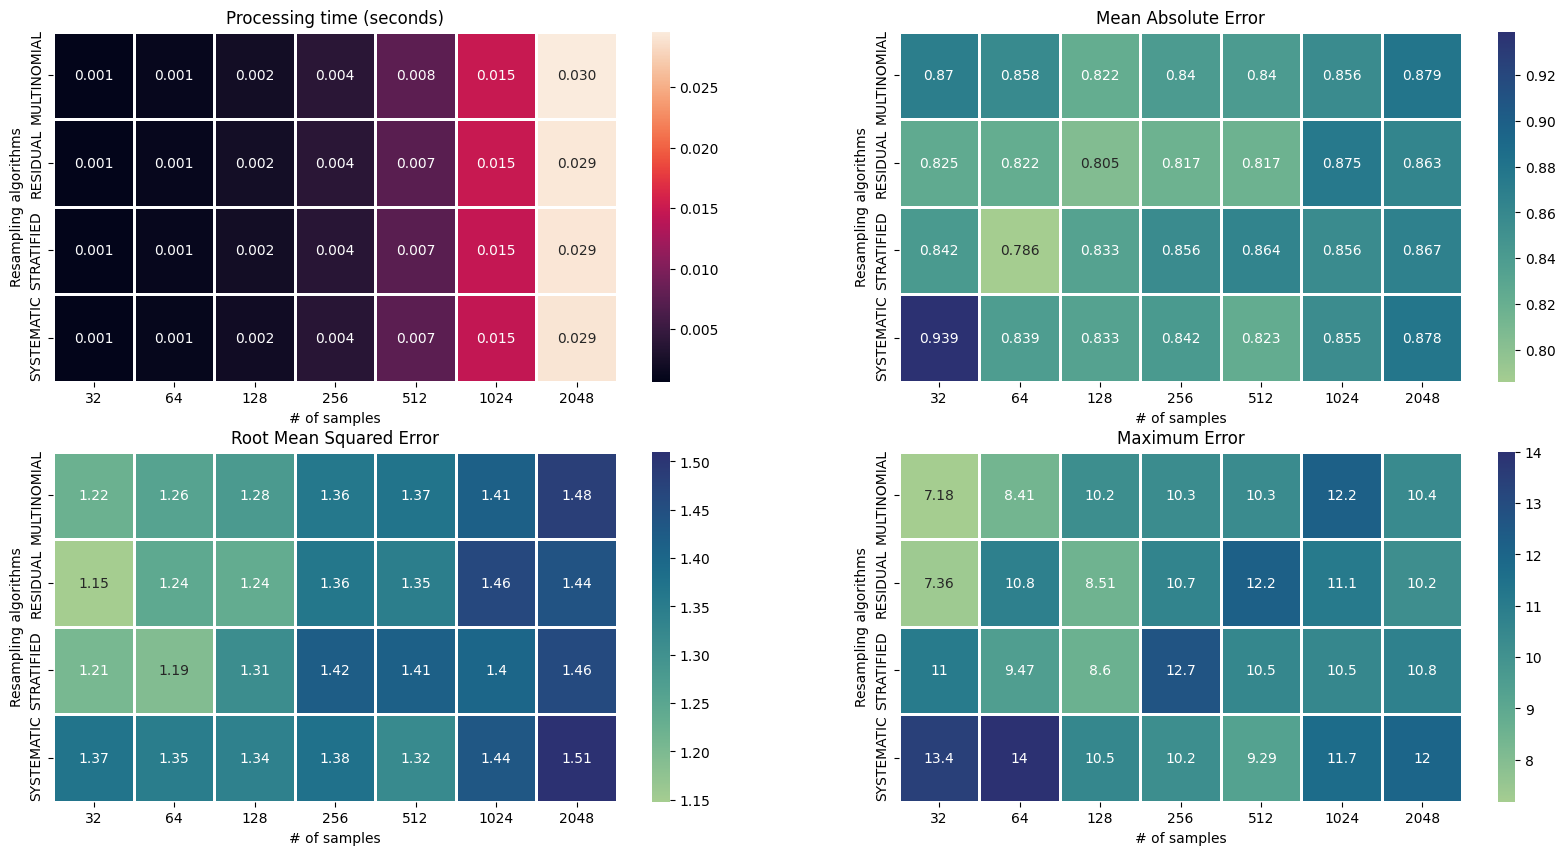

In [82]:
tuner_setup3_40.plot_results()

In [83]:
params_3_40, df_3_40 = tuner_setup3_40.find_best_combination(
    error_weight=error_weight, 
    error_upper_limit=1000)

best_params_40.append(params_3_40)

In [84]:
df_3_40

,# of samples,resampling algorithm
MAE,64,STRATIFIED
RMSE,32,RESIDUAL
MAX,32,MULTINOMIAL


# Results

In [85]:
best_params_0_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_0_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_0_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_0 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_10_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_10_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_10_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_10 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_20_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_20_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_20_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_20 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_30_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_30_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_30_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_30 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_40_mae = np.array([[params[ErrorEnum.MAE.value]['n_sample'], params[ErrorEnum.MAE.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.MAE.value]]).flatten().tolist()
best_params_40_rmse = np.array([[params[ErrorEnum.RMSE.value]['n_sample'], params[ErrorEnum.RMSE.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.RMSE.value]]).flatten().tolist()
best_params_40_max = np.array([[params[ErrorEnum.MAX.value]['n_sample'], params[ErrorEnum.MAX.value]['resampling_algorithm'].name] for params in best_params_40 if params[ErrorEnum.MAX.value]]).flatten().tolist()

best_params_mae = [best_params_0_mae, best_params_10_mae, best_params_20_mae, best_params_30_mae, best_params_40_mae]
best_params_rmse = [best_params_0_rmse, best_params_10_rmse, best_params_20_rmse, best_params_30_rmse, best_params_40_rmse]
best_params_max = [best_params_0_max, best_params_10_max, best_params_20_max, best_params_30_max, best_params_40_max]

In [86]:
best_params_mae

[['512', 'STRATIFIED', '512', 'MULTINOMIAL', '64', 'RESIDUAL'],
 ['512', 'SYSTEMATIC', '512', 'MULTINOMIAL', '256', 'STRATIFIED'],
 ['512', 'SYSTEMATIC', '512', 'STRATIFIED', '128', 'MULTINOMIAL'],
 ['512', 'MULTINOMIAL', '512', 'RESIDUAL', '64', 'RESIDUAL'],
 ['512', 'SYSTEMATIC', '512', 'STRATIFIED', '64', 'STRATIFIED']]

In [87]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS)'],
                                             ['# of samples', 'Resampling algorithm']],
                                            names=['Setups','Parameters'])


#### MAE

In [88]:
best_params_df = pd.DataFrame(best_params_mae, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)
best_params_df

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              512           STRATIFIED                 512   
10% drop                512           SYSTEMATIC                 512   
20% drop                512           SYSTEMATIC                 512   
30% drop                512          MULTINOMIAL                 512   
40% drop                512           SYSTEMATIC                 512   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout          MULTINOMIAL           64             RESIDUAL  
10% drop            MULTINOMIAL          256           STRATIFIED  
20% drop             STRATIFIED          128          MULTINOMIAL  
30% drop               RESIDUAL           64             RESIDUAL  
40% drop             STRATIFIED           64           STRATIFIED

#### RMSE

In [89]:
pd.DataFrame(best_params_rmse, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              512           STRATIFIED                 512   
10% drop                512           STRATIFIED                 512   
20% drop                512           SYSTEMATIC                 512   
30% drop                512          MULTINOMIAL                 512   
40% drop                512           SYSTEMATIC                 512   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout          MULTINOMIAL           64             RESIDUAL  
10% drop            MULTINOMIAL          128             RESIDUAL  
20% drop             STRATIFIED           64           SYSTEMATIC  
30% drop               RESIDUAL           64             RESIDUAL  
40% drop             STRATIFIED           32             RESIDUAL

#### MAX

In [90]:
pd.DataFrame(best_params_max, 
                index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                columns=results_header)

Setups     Setup1 (IMU, VO)                      Setup2(IMU, VO+GPS)  \
Parameters     # of samples Resampling algorithm        # of samples   
No dropout              512           STRATIFIED                 512   
10% drop                512           SYSTEMATIC                 512   
20% drop                512           SYSTEMATIC                 512   
30% drop                512             RESIDUAL                 512   
40% drop                512           SYSTEMATIC                 512   

Setups                           Setup3(INS)                       
Parameters Resampling algorithm # of samples Resampling algorithm  
No dropout          MULTINOMIAL           64             RESIDUAL  
10% drop            MULTINOMIAL           32           SYSTEMATIC  
20% drop             STRATIFIED           32          MULTINOMIAL  
30% drop               RESIDUAL           32             RESIDUAL  
40% drop             STRATIFIED           32          MULTINOMIAL

## Export the result

In [91]:
best_params_df.to_json(exporting_filename)

# Conclusion

In this notebook, we conducted a manual search to identify the best combination of parameters for the Particle Filter, including particle size and the resampling algorithm. We tested every combination of the following options: the number of samples (32, 64, 128, 256, 512, 1024, and 2048) and the resampling algorithms (Multinomial, Residual, Stratified, and Systematic).

After running the Particle Filter with all these combinations, we calculated an error metric for each one. Finally, we computed a weighted average of the error and processing time, with a weight ratio of 9:1.

According to the experiment, based on MAE metric, we found that the optimal parameters for each setup is:
- Setup1 (IMU, VO):
    - Number of samples    : 512
    - Resampling algorithm : SYSTEMATIC
- Setup2 (IMU, VO+GPS):
    - Number of samples    : 512
    - Resampling algorithm : STRATIFIED
- Setup3 (INS, VO+GPS):
    - Number of samples    : 64
    - Resampling algorithm : STRATIFIED

Even sensor data dropout, Setup3 performs robust estimations, where no filter divergence when number of particles is set larger than 64 in KITTI raw dataset sequence 09.

To avoid common PF problems known sa sample degeneracy and impoverishment, we can set the number fo particles to large value, say 1024 or 2048. However, particle size and computational power is trade-off so that we discover the balance between them in this experiment.